In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.preprocessing import StandardScaler,LabelEncoder

In [7]:
from sklearn.linear_model import Perceptron
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import Flatten

from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Dropout

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import SGD

In [8]:
df=pd.read_csv('train.csv')

In [9]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
df.shape

(1142, 785)

In [11]:
df.columns

Index(['label', 'pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5',
       'pixel6', 'pixel7', 'pixel8',
       ...
       'pixel774', 'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779',
       'pixel780', 'pixel781', 'pixel782', 'pixel783'],
      dtype='object', length=785)

In [12]:
df.isnull().sum()

,0
label,0
pixel0,0
pixel1,0
pixel2,0
pixel3,0
...,...
pixel779,1
pixel780,1
pixel781,1
pixel782,1


In [13]:
#preprocessing
X=df.drop(['label'],axis=1)
y=df['label']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.33,
                                                    random_state=42)

In [15]:
X_train=X_train.astype('float32')/255.0
X_test=X_test.astype('float32')/255.0

In [16]:
import numpy as np
#reshaping data
X_train_img=X_train.values.reshape(-1,28,28)
X_test_img=X_test.values.reshape(-1,28,28)

# Replace NaN values with 0 to prevent 'loss: nan' during training
X_train_img = np.nan_to_num(X_train_img, nan=0.0)
X_test_img = np.nan_to_num(X_test_img, nan=0.0)

In [17]:
X_train_img

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

In [18]:
y_train_cat=to_categorical(y_train,10)
y_test_cat=to_categorical(y_test,10)

In [19]:
Perceptron=Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10,activation='softmax')
])

In [20]:
Perceptron.compile(optimizer=SGD(learning_rate=0.001),loss='categorical_crossentropy',metrics=['accuracy'])

In [21]:
history_percp=Perceptron.fit(X_train_img,
                       y_train_cat,
                       epochs=10,
                       batch_size=32,
                       validation_data=(X_test_img,y_test_cat),verbose=1)

Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.1007 - loss: 2.3922 - val_accuracy: 0.1008 - val_loss: 2.3710
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.1137 - loss: 2.3566 - val_accuracy: 0.1141 - val_loss: 2.3386
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.1176 - loss: 2.3235 - val_accuracy: 0.1167 - val_loss: 2.3083
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.1307 - loss: 2.2921 - val_accuracy: 0.1353 - val_loss: 2.2795
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.1451 - loss: 2.2624 - val_accuracy: 0.1485 - val_loss: 2.2522
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1634 - loss: 2.2339 - val_accuracy: 0.1592 - val_loss: 2.2260
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1778 - loss: 2.2066 - val_accuracy: 0.1751 - val_loss: 2.2008
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2000 - loss: 2.1801 - val_accuracy: 0.1883 - val_

In [22]:
acc_perceptron=Perceptron.evaluate(X_test_img,y_test_cat,verbose=0)[1]

In [23]:
acc_perceptron

0.21750663220882416

In [24]:
#ANN
ANN=Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128,activation='relu'),
    Dense(64,activation='relu'),
    Dense(10,activation='softmax')
])

In [25]:
ANN.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [26]:
history_ann=ANN.fit(X_train_img,
                y_train_cat,
                epochs=10,
                batch_size=32,
                validation_data=(X_test_img,y_test_cat),verbose=1)

Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.4353 - loss: 1.8296 - val_accuracy: 0.7056 - val_loss: 1.2865
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7869 - loss: 0.8965 - val_accuracy: 0.8223 - val_loss: 0.7017
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8667 - loss: 0.5040 - val_accuracy: 0.8674 - val_loss: 0.5363
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9085 - loss: 0.3497 - val_accuracy: 0.8647 - val_loss: 0.4772
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9242 - loss: 0.2899 - val_accuracy: 0.8886 - val_loss: 0.4066
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9542 - loss: 0.2093 - val_accuracy: 0.8966 - val_loss: 0.4001
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9725 - loss: 0.1524 - val_accuracy: 0.8992 - val_loss: 0.3797
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9856 - loss: 0.1148 - val_accuracy: 0.9098 - val_loss

In [27]:
acc_ann=ANN.evaluate(X_test_img,y_test_cat,verbose=0)[1]

In [28]:
acc_ann

0.9230769276618958

In [29]:
#reshaping for cnn
X_train_cnn=X_train_img.reshape(-1,28,28,1)
X_test_cnn=X_test_img.reshape(-1,28,28,1)

In [30]:
cnn=Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64,kernel_size=(3,3),activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(10,activation='softmax')
])

In [31]:
cnn.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [32]:
history_cnn=cnn.fit(X_train_cnn,
                y_train_cat,
                epochs=5,
                batch_size=32,
                validation_data=(X_test_cnn,y_test_cat),verbose=1)

Epoch 1/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.2980 - loss: 2.0299 - val_accuracy: 0.6446 - val_loss: 1.4362
Epoch 2/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.6222 - loss: 1.1851 - val_accuracy: 0.8515 - val_loss: 0.6613
Epoch 3/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.7752 - loss: 0.6884 - val_accuracy: 0.8939 - val_loss: 0.4196
Epoch 4/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.8510 - loss: 0.5275 - val_accuracy: 0.9204 - val_loss: 0.3203
Epoch 5/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.8693 - loss: 0.3827 - val_accuracy: 0.9204 - val_loss: 0.2755


In [33]:
cnn_acc=cnn.evaluate(X_test_cnn,y_test_cat,verbose=0)[1]

In [34]:
cnn_acc

0.9204244017601013

In [35]:
def plot_training(history, title):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label="Train")
    plt.plot(history.history['val_accuracy'], label="Val")
    plt.title(f"{title} Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label="Train")
    plt.plot(history.history['val_loss'], label="Val")
    plt.title(f"{title} Loss")
    plt.legend()
    plt.show()

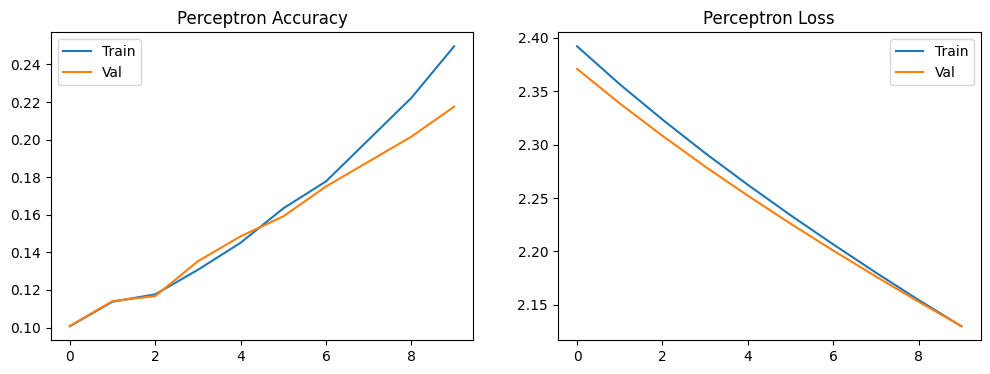

In [36]:
plot_training(history_percp, "Perceptron")

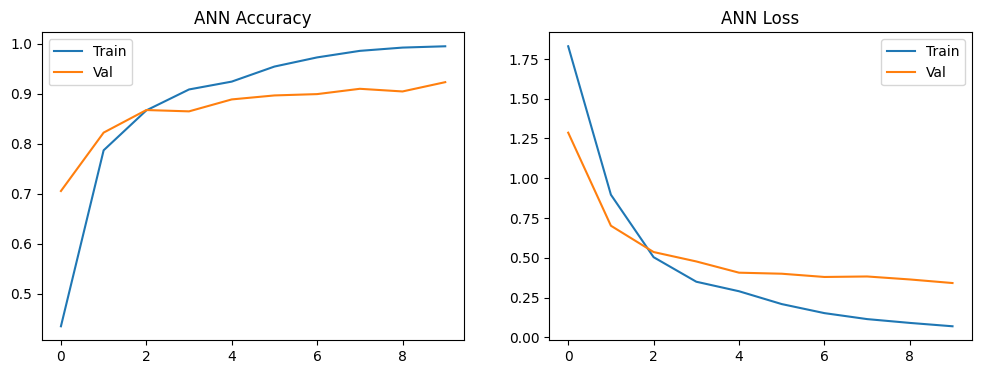

In [37]:
plot_training(history_ann, "ANN")

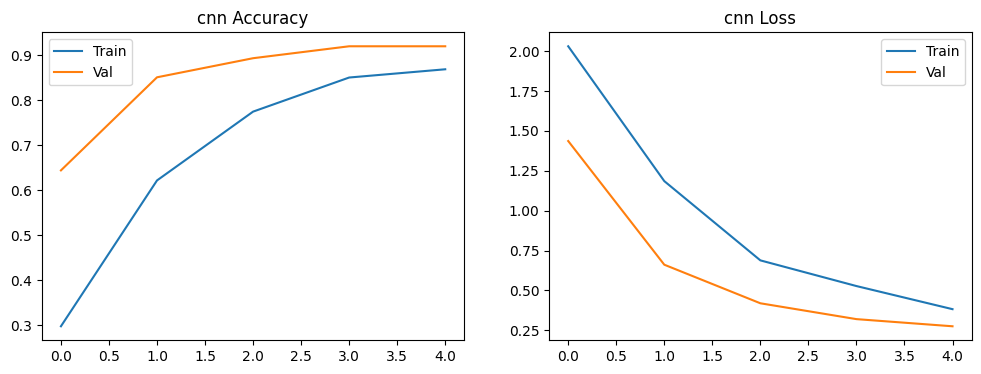

In [38]:
plot_training(history_cnn, "cnn")

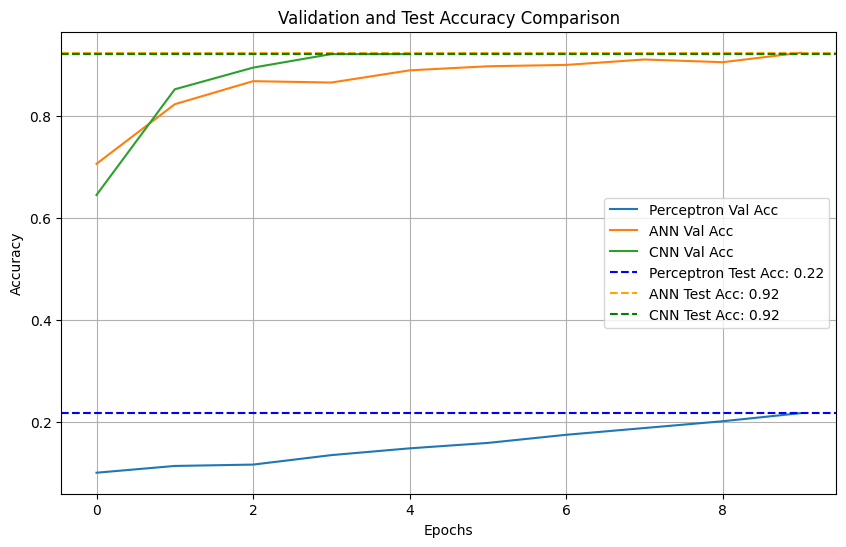

In [39]:
plt.figure(figsize=(10,6))
plt.plot(history_percp.history['val_accuracy'], label="Perceptron Val Acc")
plt.plot(history_ann.history['val_accuracy'], label="ANN Val Acc")
plt.plot(history_cnn.history['val_accuracy'], label="CNN Val Acc")

# Add horizontal lines for final test accuracies
plt.axhline(y=acc_perceptron, color='blue', linestyle='--', label=f'Perceptron Test Acc: {acc_perceptron:.2f}')
plt.axhline(y=acc_ann, color='orange', linestyle='--', label=f'ANN Test Acc: {acc_ann:.2f}')
plt.axhline(y=cnn_acc, color='green', linestyle='--', label=f'CNN Test Acc: {cnn_acc:.2f}')

plt.title("Validation and Test Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [40]:
def show_side_by_side(models, model_names, X, X_cnn, y_true, n=5):
    idxs = np.random.choice(len(X), n, replace=False)
    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(idxs):
        plt.subplot(2, n, i+1)
        plt.imshow(X[idx].reshape(28, 28), cmap="gray")
        plt.axis("off")
        plt.title(f"True: {y_true.iloc[idx]}") # Changed to .iloc[idx]
        preds = [np.argmax(model.predict(X_cnn[idx].reshape(1, 28, 28, 1) if name == "CNN" else X[idx].reshape(1, 28, 28)))
                 for model, name in zip(models, model_names)]
        plt.subplot(2, n, n+i+1)
        plt.axis("off")
        plt.title("\n".join(f"{n}: {p}" for n, p in zip(model_names, preds)))
    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


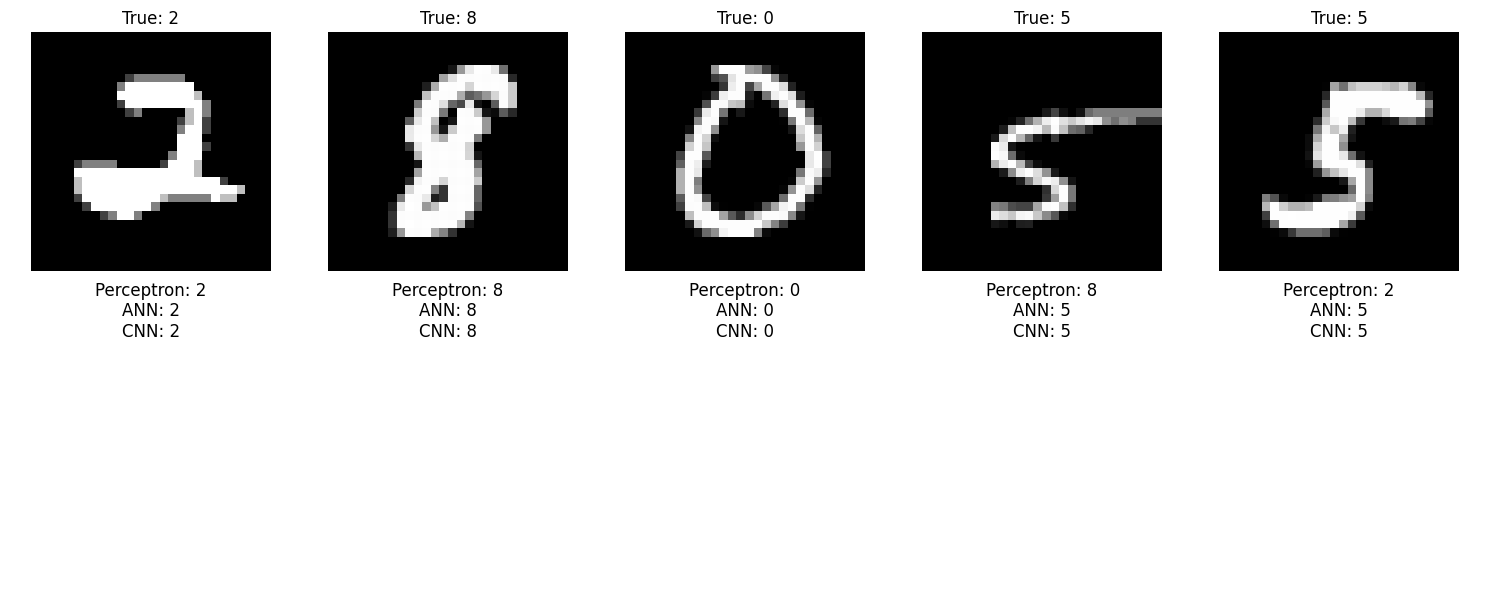

In [41]:
show_side_by_side([Perceptron, ANN, cnn], ["Perceptron", "ANN", "CNN"], X_test_img, X_test_cnn, y_test, 5)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


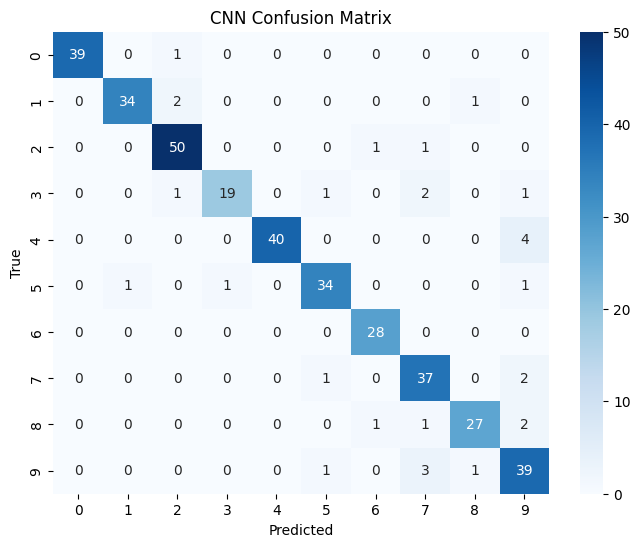

In [42]:
y_pred_cnn = np.argmax(cnn.predict(X_test_cnn), axis=1)
cm = confusion_matrix(y_test, y_pred_cnn)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


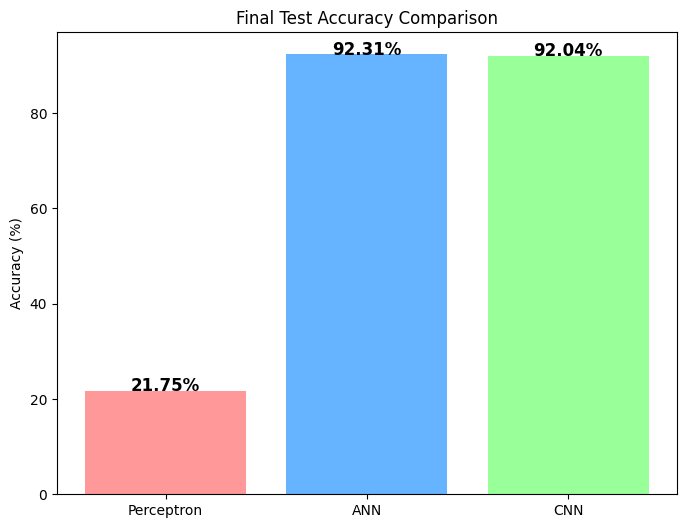

In [43]:
final_accs = [acc_perceptron*100, acc_ann*100, cnn_acc*100]
models = ["Perceptron", "ANN", "CNN"]

plt.figure(figsize=(8,6))
bars = plt.bar(models, final_accs, color=['#ff9999','#66b3ff','#99ff99'])
plt.title("Final Test Accuracy Comparison")
plt.ylabel("Accuracy (%)")
for bar, acc in zip(bars, final_accs):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()-1, f"{acc:.2f}%",
             ha='center', va='bottom', fontsize=12, fontweight='bold')
# plt.ylim(80, 100) # Removed this line to show all bars
plt.show()

In [44]:
from tensorflow.keras.models import save_model

save_model(Perceptron, 'perceptron_model.h5')
print("Perceptron model saved successfully as 'perceptron_model.h5'")

Perceptron model saved successfully as 'perceptron_model.h5'


In [45]:
save_model(ANN, 'ann_model.h5')
print("ANN model saved successfully as 'ann_model.h5'")

ANN model saved successfully as 'ann_model.h5'


In [46]:
from tensorflow.keras.models import save_model

save_model(cnn, 'cnn_model.keras')
print("CNN model saved successfully as 'cnn_model.keras'")

CNN model saved successfully as 'cnn_model.keras'


In [50]:
import tf2onnx
import tensorflow as tf
import os

# ── Save as SavedModel first (workaround for tf2onnx KeyError bug) ──
ANN.export("ann_saved")
cnn.export("cnn_saved")

# ── Convert ANN ──
os.system("python -m tf2onnx.convert --saved-model ann_saved --output ann_model.onnx --opset 13")

# ── Convert CNN ──
os.system("python -m tf2onnx.convert --saved-model cnn_saved --output cnn_model.onnx --opset 13")

# ── Download ──
from google.colab import files
files.download('ann_model.onnx')
files.download('cnn_model.onnx')
print("✅ Done!")

Saved artifact at 'ann_saved'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28), dtype=tf.float32, name='keras_tensor_3')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  138858528614224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138858528612112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138858528611152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138858528606160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138858528617104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138858528616336: TensorSpec(shape=(), dtype=tf.resource, name=None)
Saved artifact at 'cnn_saved'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name='keras_tensor_8')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  138858528615184: TensorSp

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Done!
